In [46]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

df = pd.DataFrame(data= iris.data, columns= feature_names)
df['target'] = iris.target

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [47]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3,
                      random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

df['gmm_cluster'] = gmm_cluster_labels

res = df.groupby(['target'])['gmm_cluster'].value_counts()
print(res)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [48]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                max_iter=300,
                random_state=42).fit(iris.data)

kmeans_cluster_labels = kmeans.predict(iris.data)
df['kmeans_cluster'] = kmeans_cluster_labels
res = df.groupby(['target'])['kmeans_cluster'].value_counts()
print(res)

target  kmeans_cluster
0       1                 50
1       2                 47
        0                  3
2       0                 36
        2                 14
Name: count, dtype: int64


In [49]:
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_
        
    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)
        
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)
        
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'
    
    plt.legend(loc=legend_loc)
    plt.show()

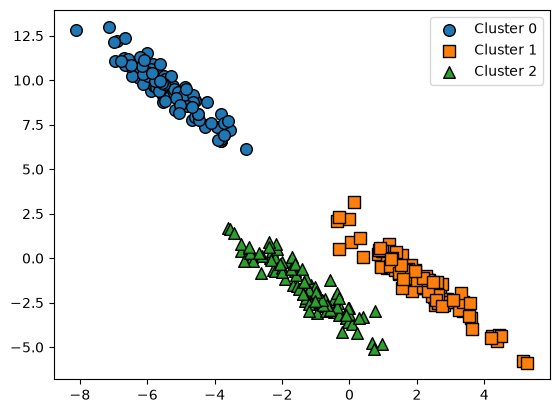

In [50]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300,
                  n_features=2,
                  centers=3,
                  cluster_std=1.5,
                  random_state=42)

transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X_trans = np.dot(X, transformation)

df = pd.DataFrame(data = X_trans, columns= ['ftr1', 'ftr2'])
df['target'] = y

visualize_cluster_plot(None, df, 'target', iscenter=False)

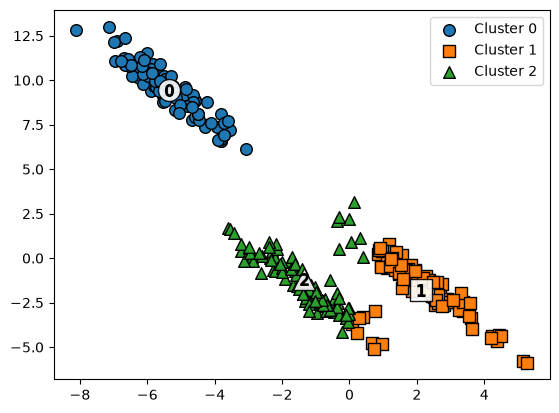

In [51]:
kmeans = KMeans(3, random_state=42)
kmeans_labels = kmeans.fit_transform(X_trans)
df['kmeans_label'] = kmeans.labels_

visualize_cluster_plot(kmeans, df, 'kmeans_label', iscenter=True)

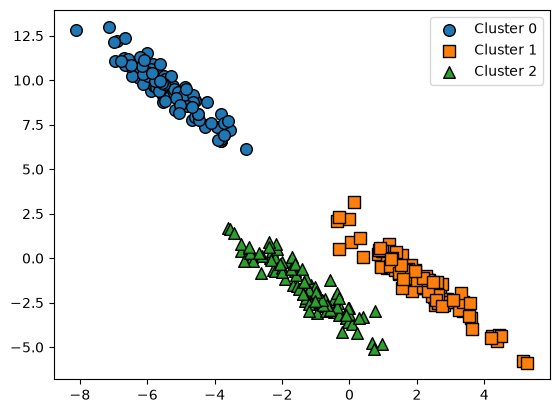

In [52]:
gmm = GaussianMixture(n_components=3,
                      random_state=42)
gmm_label = gmm.fit_predict(X_trans)
df['gmm_label'] = gmm_label

visualize_cluster_plot(gmm, df, 'gmm_label', iscenter= False)

In [54]:
print(df.groupby('target')['kmeans_label'].value_counts())
print(df.groupby('target')['gmm_label'].value_counts())

target  kmeans_label
0       0               100
1       1                92
        2                 8
2       2                92
        1                 8
Name: count, dtype: int64
target  gmm_label
0       0            100
1       1            100
2       2            100
Name: count, dtype: int64
